In [2]:
##leanring things about new cluster 

In [3]:
import sys
from scipy.stats import sem
sys.path.append('/Users/michaelfinch/CA1-interneuron-GLM')

from utils_TCA_clustering_scratchpad import *
from GLM_regression_plotting import *


from modelling_to_date_utils import *

import os, time, sys, platform

# activity_dict, double_predicted_activity_dict_NDNF_new, filtered_factors_dict, double_new_NDNF_activity_dict, double_new_NDNF_velocity_dict, double_residual_activity_dict_NDNF_new = load_data_double(name="NDNFanalC", double_track=False)
# activity_dict, filtered_factors_dict, double_new_NDNF_activity_dict_100, double_new_NDNF_velocity_dict_100, double_residual_activity_dict_NDNF_new_100 = load_data_double(name="NDNFanalC", double_track=True)

# GLM_params, activity_dict, double_predicted_activity_dict_NDNF_new, factors_dict, filtered_factors_dict, residual_activity_dict_NDNF_new = load_data_regular(name="NDNFanalC", new_NDNF=True)
# GLM_params_old_NDNF, activity_dict_old_NDNF, double_predicted_activity_dict_NDNF_old, factors_dict_old_NDNF, filtered_factors_dict_old_NDNF, residual_activity_dict_NDNF_old = load_data_regular(name="NDNFindivsomata_GLM", new_NDNF=False)
GLM_params_SST, activity_dict_SST, double_predicted_activity_dict_SST, factors_dict_SST, filtered_factors_dict_SST, residual_activity_dict_SST = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="SSTindivsomata_GLM", new_NDNF=False)
GLM_params_EC, activity_dict_EC, double_predicted_activity_dict_EC, factors_dict_EC, filtered_factors_dict_EC, residual_activity_dict_EC = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="EC_GLM", new_NDNF=False)


GLM_params_SST, activity_dict_SST, double_predicted_activity_dict_SST, factors_dict_SST, filtered_factors_dict_SST, residual_activity_dict_SST = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="SSTindivsomata_GLM", new_NDNF=False)
GLM_params_EC, activity_dict_EC, double_predicted_activity_dict_EC, factors_dict_EC, filtered_factors_dict_EC, residual_activity_dict_EC = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="EC_GLM", new_NDNF=False)


GLM_params_NDNF_newest, activity_dict_NDNF_newest, double_predicted_activity_dict_NDNF_newest, factors_dict_NDNF_newest, filtered_factors_dict_NDNF_newest, residual_activity_dict_NDNF_newest = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="NDNF_E1A1B", new_NDNF=True)

fixed_residual_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(residual_activity_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_residual_activity_dict_NDNF_newest[f"animal_{idx+1}"] = residual_activity_dict_NDNF_newest[animal]

fixed_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(activity_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_activity_dict_NDNF_newest[f"animal_{idx+1}"] = activity_dict_NDNF_newest[animal]

fixed_filtered_factors_dict_NDNF_newest = {}
for idx, animal in enumerate(filtered_factors_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_filtered_factors_dict_NDNF_newest[f"animal_{idx+1}"] = filtered_factors_dict_NDNF_newest[animal]


fixed_factors_dict_NDNF_newest = {}
for idx, animal in enumerate(factors_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_factors_dict_NDNF_newest[f"animal_{idx+1}"] = factors_dict_NDNF_newest[animal]


/Users/michaelfinch/CA1-interneuron-GLM/utils.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [4]:
save_path="/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/pickle_every_slice_type_NDNF.pkl"

with open (save_path, 'rb') as f:
    model_and_mse_dict_NDNF = pickle.load(f)
    print(save_path)

/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/pickle_every_slice_type_NDNF.pkl


In [5]:
import sys
import os

current_dir = os.getcwd()

parent_dir = os.path.join(current_dir, "Clean_notebooks_to_date")
sys.path.append(parent_dir)

from comparing_slice_TCA_methods import *



In [6]:
model_20_NDNF_raw_0x0 = model_and_mse_dict_NDNF[20]['model']
labels_cells_dict_all_K_NDNF_0x0_raw = get_labels_all_different_Ks_single(model_20_NDNF_raw_0x0, which_vectors=1)


F.shape (20, 100, 50)  W.shape (20, 115)
X shape (mean over pos): (115, 20)


/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


In [7]:
data_truncated_array_NDNF = get_truncated_to_min_data_array(fixed_residual_activity_dict_NDNF_newest)


In [8]:

def get_r_list(fixed_activity_dict_NDNF_newest, factors_dict_NDNF_newest, data_truncated_array_EC, data_to_corr=None):

    r_list_vel = []
    vel_per_animal = []
    for animal in fixed_activity_dict_NDNF_newest:
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            vel = factors_dict_NDNF_newest[animal][data_to_corr][:,:data_truncated_array_EC.shape[2]]
            vel_per_animal.append(vel)
            data = fixed_activity_dict_NDNF_newest[animal][cell][:,:data_truncated_array_EC.shape[2]]
            r, _ = pearsonr(vel.flatten(), data.flatten())
            r_list_vel.append(r)

    array_data = np.array(vel_per_animal)
    r_dict_vel = {"r_list":r_list_vel,
                  "array_data":array_data}

    return r_dict_vel


r_dict_vel = get_r_list(fixed_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest, data_truncated_array_NDNF, data_to_corr="Velocity")
r_dict_licks = get_r_list(fixed_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest, data_truncated_array_NDNF, data_to_corr="Licks")
            

r_dict_vel_resid = get_r_list(fixed_residual_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest, data_truncated_array_NDNF, data_to_corr="Velocity")
r_dict_licks_resid = get_r_list(fixed_residual_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest, data_truncated_array_NDNF, data_to_corr="Licks")

In [9]:
labels_for_two = labels_cells_dict_all_K_NDNF_0x0_raw[2]

labels_zero = np.where(labels_for_two==0)[0]
labels_one = np.where(labels_for_two==1)[0]

def get_NDNF_activity(fixed_residual_activity_dict_NDNF_newest, labels_zero, labels_one):
    NDNF_raw_list = []
    for animal in fixed_residual_activity_dict_NDNF_newest:
        for cell in fixed_residual_activity_dict_NDNF_newest[animal]:
            NDNF_raw_list.append(fixed_residual_activity_dict_NDNF_newest[animal][cell][:,:58].flatten())

    NDNF_raw_array = np.array(NDNF_raw_list)

    sliced_zero = NDNF_raw_array[np.array(labels_zero)]
    sliced_one =  NDNF_raw_array[np.array(labels_one)]

    return sliced_zero, sliced_one

sliced_zero, sliced_one = get_NDNF_activity(fixed_residual_activity_dict_NDNF_newest, labels_zero, labels_one)

# NDNF_parsed_zero = NDNF_raw_list[0]
# NDNF_parsed_one = NDNF_raw_list[1]

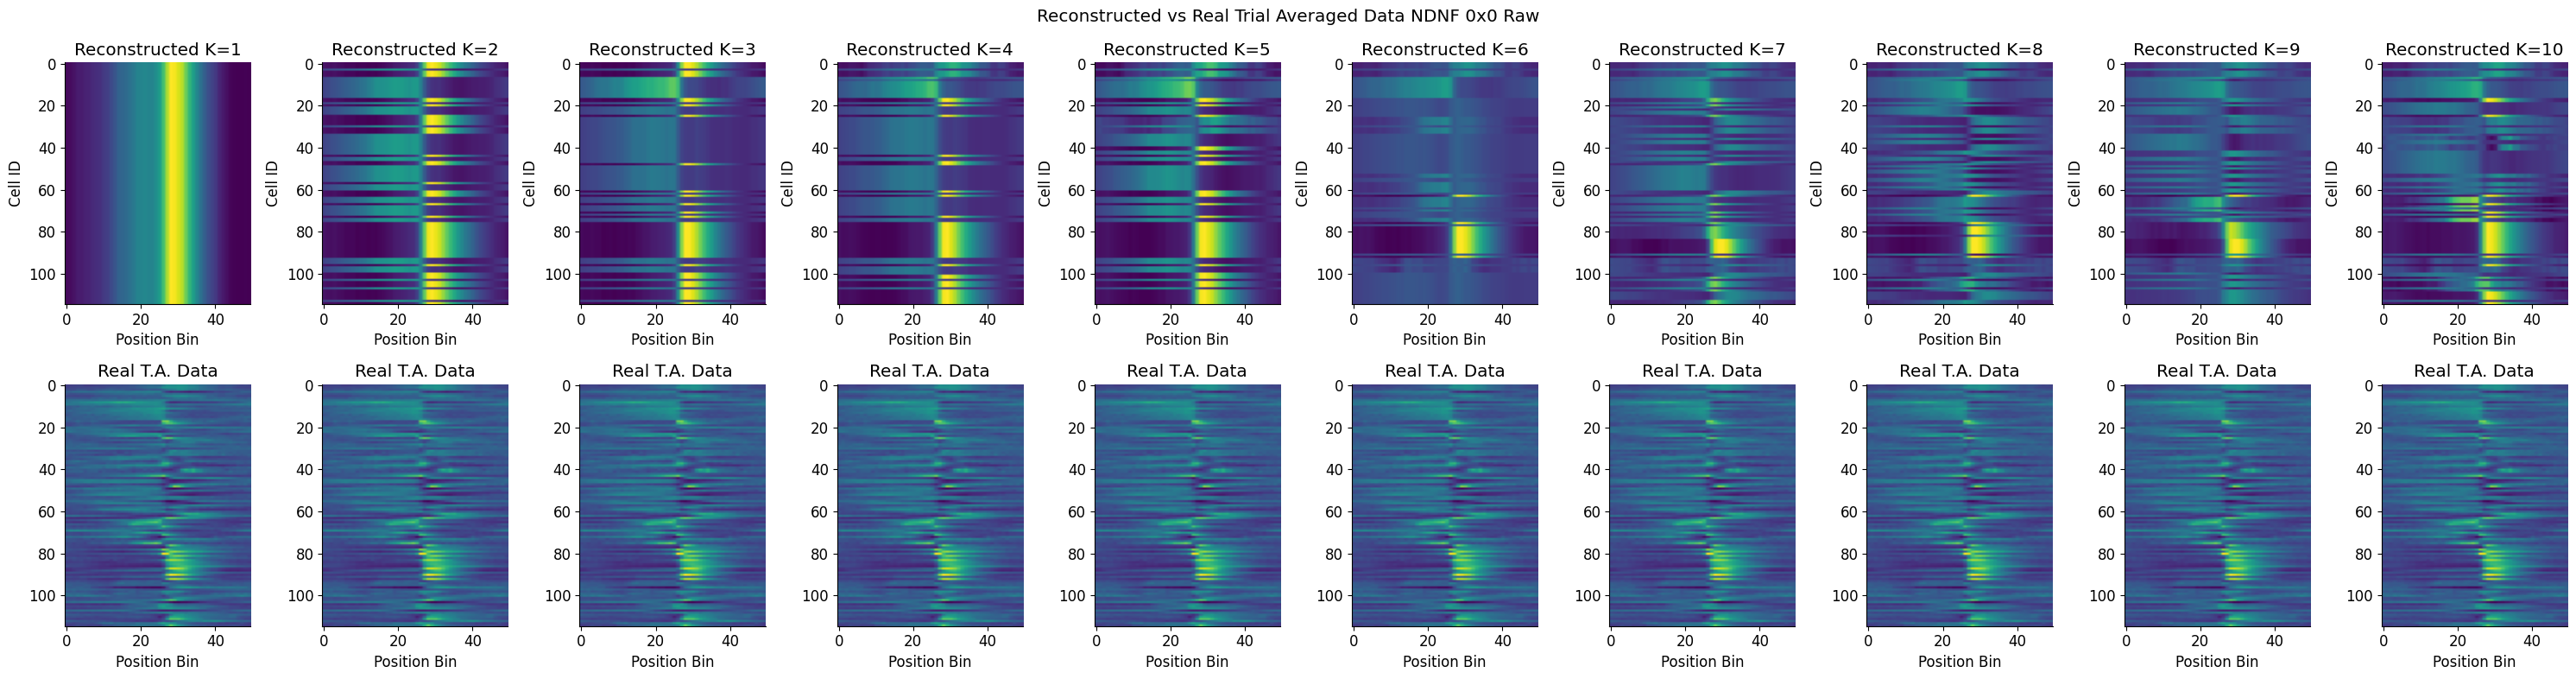

In [10]:
means_dict_cluster_0x0_raw = plot_reconstructions(labels_cells_dict_all_K_NDNF_0x0_raw, fixed_activity_dict_NDNF_newest, r_dict_vel, r_dict_licks, prefix="NDNF 0x0 Raw")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def fit_GLM2(EC_data_array, neuron_activity_flat, regression='linear', alphas=None):
    
    design_matrix_X = EC_data_array.T
    
    if regression == 'linear':
        model = LinearRegression()
    elif regression == 'lasso':
        model = LassoCV(alphas=alphas, cv=None) if alphas is not None else LassoCV(cv=None)
    elif regression == 'ridge':
        model = RidgeCV(alphas=alphas if alphas is not None else [0.1, 1, 10, 100, 1000, 5000], cv=None)
    elif regression == 'elastic':
        l1_ratio = [0.1, 0.3, 0.5, 0.7, 0.9, 1]
        model = ElasticNetCV(alphas=alphas if alphas is not None else [0.1, 1, 10, 100, 1000, 5000],
                             l1_ratio=l1_ratio, cv=None)

    model.fit(design_matrix_X, neuron_activity_flat)
    neuron_predicted_activity = model.predict(design_matrix_X)
    
    return model, neuron_predicted_activity

def get_model_dict(EC_data_array, NDNF_cluster_array, reg_type="ridge"):
    cell_model_EC = {}
    for cell in range(NDNF_cluster_array.shape[1]):
        neuron_activity = NDNF_cluster_array[:,cell]
        print(f"neuron_activity.shape {neuron_activity.shape}")
        print(f"EC_data_array.shape {EC_data_array.shape}")
        model_NDNF, neuron_predicted_activity = fit_GLM2(EC_data_array, neuron_activity, regression=reg_type, alphas=None)
        cell_model_EC[cell] = {"model":model_NDNF,
                                "pred_activity":neuron_predicted_activity}
    
    return cell_model_EC


def get_data_array_trial_av(residual_activity_dict_EC, min_trial=58):

    EC_data_list = []

    for animal in residual_activity_dict_EC:
        for cell in residual_activity_dict_EC[animal]:
            EC_truncated = residual_activity_dict_EC[animal][cell][:,:min_trial]
            # EC_data_list.append(np.mean(EC_truncated, axis=1))
            EC_data_list.append(EC_truncated.flatten())

    EC_data_array = np.array(EC_data_list)

    return EC_data_array


def get_pred_as_array(models_clusters_zero):
    pred_list_zero = []
    for i in range(len(models_clusters_zero)):
        data = models_clusters_zero[i]["pred_activity"]
        pred_list_zero.append(data)

    pred_array = np.array(pred_list_zero).T
    return pred_array


def get_mse_list(pred_array_zero, real_array_zero):
    MSE_list = []
    for i in range(pred_array_zero.shape[1]):
        pred_data = pred_array_zero[:,i]
        real_data = real_array_zero[:,i]
        
        mse = np.mean(np.square(real_data-pred_data))
        MSE_list.append(mse)
    return MSE_list



def plot_two_violins(data_a, data_b, labels=("Cond 0", "Cond 1"), title=None, cell_type="SST Input"):
    # Prepare data
    data = [np.asarray(data_a), np.asarray(data_b)]
    positions = [1, 2]

    # Create figure (single plot, no subplots)
    fig, ax = plt.subplots(figsize=(5, 4))

    # Violin plot (no internal means/extrema; we'll add our own)
    vp = ax.violinplot(
        data,
        positions=positions,
        showmeans=False,
        showmedians=False,
        showextrema=False
    )

    # Optional: give the violins a bit of transparency for readability
    for body in vp['bodies']:
        body.set_alpha(0.7)

    # Compute and plot means in red
    means = [np.mean(d) for d in data]
    ax.scatter(positions, means, color="red", zorder=3, label="Mean")
    # small horizontal line for each mean
    for x, m in zip(positions, means):
        ax.plot([x - 0.08, x + 0.08], [m, m], color="red", linewidth=2)

    # Tidy up axes
    ax.set_xticks(positions)
    ax.set_xticklabels(labels)
    ax.set_xlabel("Condition")
    ax.set_ylabel("MSE")
    ax.set_title(f"MSE {cell_type} Flat GLM Prediction vs Flat Real p={title:.3f}")
    ax.grid(True, axis="y", linestyle="--", alpha=0.3)
    ax.legend(loc="best")

    plt.tight_layout()
    plt.show()

def get_mean_sem(pred_array_zero, pred_array_one):
    pred_array_zero = pred_array_zero.reshape(50, 58, 59)
    pred_array_one = pred_array_one.reshape(50, 58, 56)

    pred_array_zero_cells = np.mean(pred_array_zero, axis=2)
    pred_array_one_cells = np.mean(pred_array_one, axis=2)

    mean_pred_array_zero_ta = np.mean(pred_array_zero_cells, axis=1)
    sem_pred_array_zero_ta = sem(pred_array_zero_cells, axis=1)

    mean_pred_array_one_ta = np.mean(pred_array_one_cells, axis=1)
    sem_pred_array_one_ta = sem(pred_array_one_cells, axis=1)

    return mean_pred_array_zero_ta, sem_pred_array_zero_ta, mean_pred_array_one_ta, sem_pred_array_one_ta

def plot_the_activity(mean_pred_array_zero_ta, sem_pred_array_zero_ta, mean_pred_array_one_ta, sem_pred_array_one_ta,mean_real_array_zero_ta, sem_real_array_zero_ta, mean_real_array_one_ta, sem_real_array_one_ta, MSE_list_zero, MSE_list_one, cell_type="SST Input"):
    fig, axs = plt.subplots(1,2, figsize=(10,5))
    plt.suptitle(f"Predicting NDNF Cell From {cell_type}")

    axs[0].plot(mean_pred_array_zero_ta, label='prediction')
    axs[0].fill_between(range(len(mean_pred_array_zero_ta)), mean_pred_array_zero_ta+sem_pred_array_zero_ta, mean_pred_array_zero_ta-sem_pred_array_zero_ta, alpha=0.2)
    axs[0].plot(mean_real_array_zero_ta, label='real')
    axs[0].fill_between(range(len(mean_real_array_zero_ta)), mean_real_array_zero_ta+sem_real_array_zero_ta, mean_real_array_zero_ta-sem_real_array_zero_ta, alpha=0.2)
    axs[0].set_title(f"Cluster 0 Average MSE={np.mean(MSE_list_zero):.3f}")
    axs[0].legend()

    axs[1].plot(mean_pred_array_one_ta, label='prediction')
    axs[1].fill_between(range(len(mean_pred_array_one_ta)), mean_pred_array_one_ta+sem_pred_array_one_ta, mean_pred_array_one_ta-sem_pred_array_one_ta, alpha=0.2)
    axs[1].plot(mean_real_array_one_ta, label='real')
    axs[1].fill_between(range(len(mean_real_array_one_ta)), mean_real_array_one_ta+sem_real_array_one_ta, mean_real_array_one_ta-sem_real_array_one_ta, alpha=0.2)
    axs[1].set_title(f"Cluster 1 Average MSE={np.mean(MSE_list_one):.3f}")
    axs[1].legend()

    plt.tight_layout()
    plt.show()

neuron_activity.shape (2900,)
EC_data_array.shape (75, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (75, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (75, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (75, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (75, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (75, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (75, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (75, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (75, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (75, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (75, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (75, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (75, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (75, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (75, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (75, 2900)
neuron_activity.shape (2

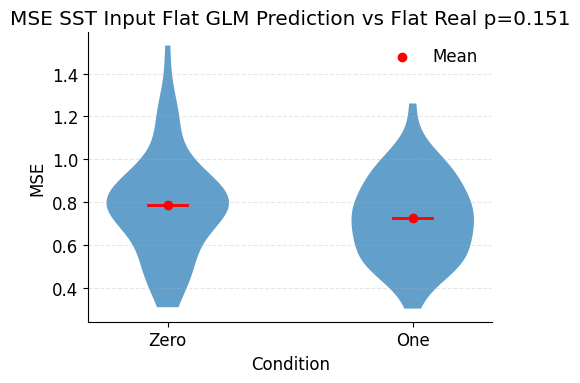

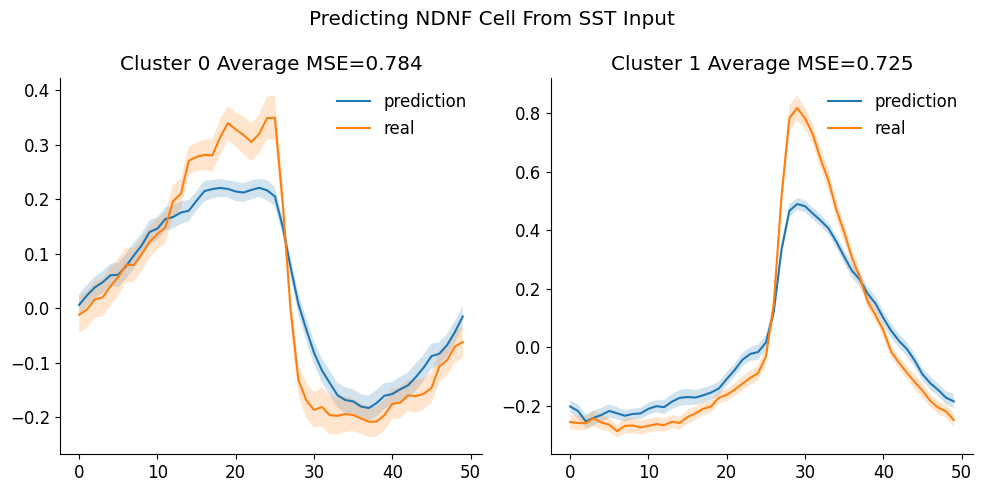

In [24]:

from scipy import stats

NDNF_cluster_array_zero, NDNF_cluster_array_one = get_NDNF_activity(fixed_activity_dict_NDNF_newest, labels_zero, labels_one)

SST_trial_av_array = get_data_array_trial_av(activity_dict_SST, min_trial=58)
EC_trial_av_array = get_data_array_trial_av(activity_dict_EC, min_trial=58)
random_trial_av_array = np.random.rand(SST_trial_av_array.shape[0], SST_trial_av_array.shape[1])

def handle_everything(SST_trial_av_array, NDNF_cluster_array_zero, NDNF_cluster_array_one, cell_type=None):
    models_clusters_zero = get_model_dict(SST_trial_av_array, NDNF_cluster_array_zero.T, reg_type="ridge")
    models_clusters_one = get_model_dict(SST_trial_av_array, NDNF_cluster_array_one.T, reg_type="ridge")


    pred_array_zero = get_pred_as_array(models_clusters_zero)
    pred_array_one = get_pred_as_array(models_clusters_one)

    MSE_list_zero = get_mse_list(pred_array_zero, NDNF_cluster_array_zero.T)
    MSE_list_one = get_mse_list(pred_array_one, NDNF_cluster_array_one.T)


    t_stat, p_val = stats.ttest_ind(np.array(MSE_list_zero), np.array(MSE_list_one), equal_var=True)

    # Call it with your lists:
    plot_two_violins(MSE_list_zero, MSE_list_one, labels=("Zero", "One"), title=p_val, cell_type=cell_type)

    mean_pred_array_zero_ta, sem_pred_array_zero_ta, mean_pred_array_one_ta, sem_pred_array_one_ta, = get_mean_sem(pred_array_zero, pred_array_one)
    mean_real_array_zero_ta, sem_real_array_zero_ta, mean_real_array_one_ta, sem_real_array_one_ta = get_mean_sem(NDNF_cluster_array_zero.T, NDNF_cluster_array_one.T)

    plot_the_activity(mean_pred_array_zero_ta, sem_pred_array_zero_ta, mean_pred_array_one_ta, sem_pred_array_one_ta,mean_real_array_zero_ta, sem_real_array_zero_ta, mean_real_array_one_ta, sem_real_array_one_ta, MSE_list_zero, MSE_list_one, cell_type=cell_type)

handle_everything(SST_trial_av_array, NDNF_cluster_array_zero, NDNF_cluster_array_one, cell_type="SST Input")



neuron_activity.shape (2900,)
EC_data_array.shape (792, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (792, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (792, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (792, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (792, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (792, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (792, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (792, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (792, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (792, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (792, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (792, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (792, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (792, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (792, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (792, 2900)
neuron_a

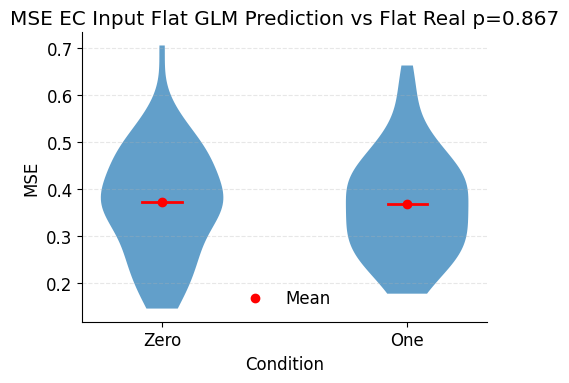

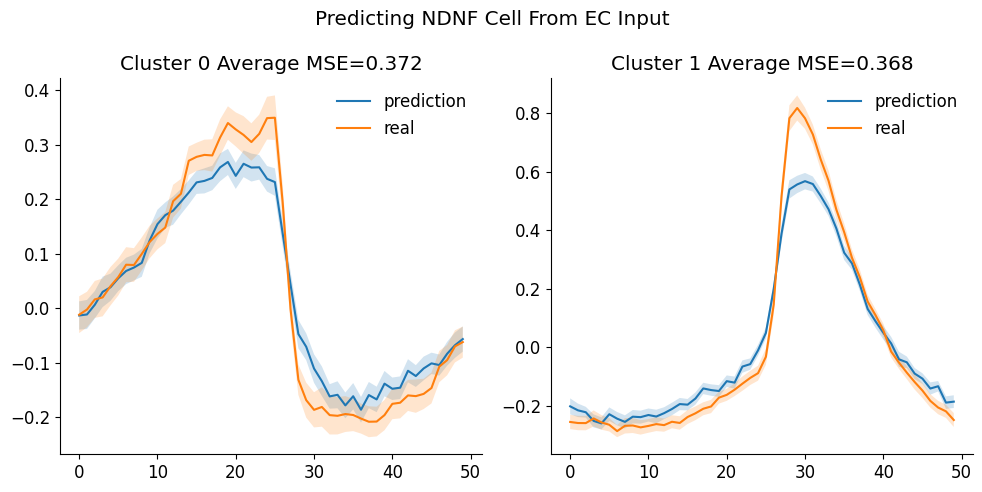

In [25]:
handle_everything(EC_trial_av_array, NDNF_cluster_array_zero, NDNF_cluster_array_one, cell_type="EC Input")

neuron_activity.shape (2900,)
EC_data_array.shape (75, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (75, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (75, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (75, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (75, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (75, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (75, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (75, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (75, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (75, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (75, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (75, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (75, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (75, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (75, 2900)
neuron_activity.shape (2900,)
EC_data_array.shape (75, 2900)
neuron_activity.shape (2

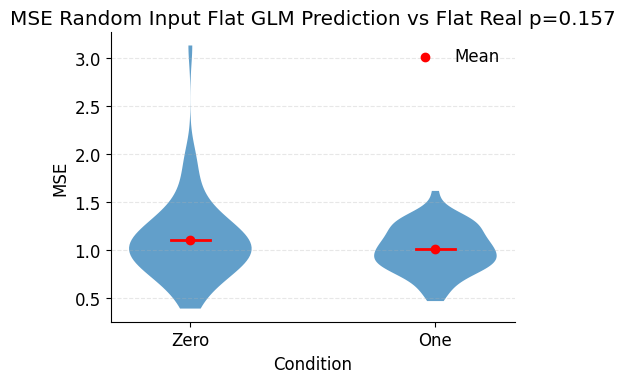

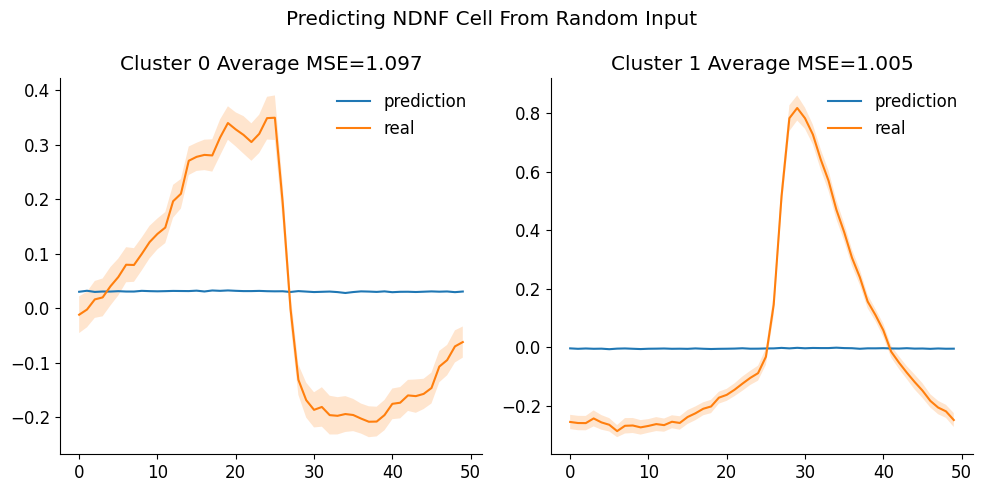

In [26]:
handle_everything(random_trial_av_array, NDNF_cluster_array_zero, NDNF_cluster_array_one, cell_type="Random Input")

In [5]:

mse_dir = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell'
testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell = get_model_data_per_cell(mse_dir)

mse_dir ='/Users/michaelfinch/CA1-interneuron-GLM/datasets/testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell'
testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell = get_model_data_per_cell(mse_dir)

mse_dir ='/Users/michaelfinch/CA1-interneuron-GLM/datasets/real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell'
real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell = get_model_data_per_cell(mse_dir)

fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue = {20: {}}
for idx, animal in enumerate(real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell[20]):
    if 17<idx<31:
        fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue[20][animal-18] = real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell[20][animal]

Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 5 cells
    Animal 1: 15 cells
    Animal 2: 6 cells
    Animal 3: 4 cells
    Animal 4: 13 cells
    Animal 5: 13 cells
    Animal 6: 3 cells
    Animal 7: 3 cells
    Animal 8: 3 cells
    Animal 9: 10 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 192 cells
    Animal 1: 150 cells
    Animal 2: 154 cells
    Animal 3: 82 cells
    Animal 4: 74 cells
    Animal 5: 64 cells
    Animal 6: 76 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 12 cells
    Animal 1: 16 cells
    Animal 2: 4 cells
    Animal 3: 10 cells
    Animal 4: 8 cells
    Animal 5: 7 cells
    Animal 6: 11 cells
    Animal 7: 10 cells
    Animal 8: 17 cells
    Animal 9: 17 cells
    Animal 10: 9 cells
    Animal 11: 6 cells
    Animal 12: 10 cells
    Animal 13: 9 cells
    Animal 14: 6 cells
    Animal 15: 12 cells
    Animal 16: 7 cells
    Animal 17: 7 cells
    Animal 18: 7 cells
    Animal 19: 10 cells
    Animal 20: 9 cells
    Animal 21: 

In [62]:

mse_dir = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/cell_SST_model_ranks20_contig_x00_cells'
cell_SST_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

mse_dir = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/cell_EC_model_ranks20_contig_x00_cells'
cell_EC_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)


mse_dir = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/real_final_NDNF_model_ranks20_contig_x00_cell'
cell_NDNF_model_ranks20_contig_x00_cue = get_model_data_per_cell(mse_dir)

    
fixed_cell_NDNF_model_ranks20_contig_x00_cue = {20: {}}
for idx, animal in enumerate(cell_NDNF_model_ranks20_contig_x00_cue[20]):
    if 17<idx<31:
        fixed_cell_NDNF_model_ranks20_contig_x00_cue[20][animal-18] = cell_NDNF_model_ranks20_contig_x00_cue[20][animal]

def get_cp_dict(cell_SST_model_ranks20_contig_x00):
    changepoints_dict = {}
    for animal in cell_SST_model_ranks20_contig_x00[20]:
        changepoints_cell_dict = {}
        for cell in cell_SST_model_ranks20_contig_x00[20][animal]:
            labels = cell_SST_model_ranks20_contig_x00[20][animal][cell][1][f'cell_{cell}']["labels_dict"]["clusters_chosen_3"]
            changepoints = np.where(np.diff(labels) != 0)[0]
            changepoints_cell_dict[cell] = changepoints
        changepoints_dict[animal] = changepoints_cell_dict

    return changepoints_dict


cp_dict_EC = get_cp_dict(cell_EC_model_ranks20_contig_x00)
cp_dict_NDNF = get_cp_dict(fixed_cell_NDNF_model_ranks20_contig_x00_cue)
cp_dict_SST = get_cp_dict(cell_SST_model_ranks20_contig_x00)

Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 5 cells
    Animal 1: 15 cells
    Animal 2: 6 cells
    Animal 3: 4 cells
    Animal 4: 13 cells
    Animal 5: 13 cells
    Animal 6: 3 cells
    Animal 7: 3 cells
    Animal 8: 3 cells
    Animal 9: 10 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 192 cells
    Animal 1: 150 cells
    Animal 2: 154 cells
    Animal 3: 82 cells
    Animal 4: 74 cells
    Animal 5: 64 cells
    Animal 6: 76 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 12 cells
    Animal 1: 16 cells
    Animal 2: 4 cells
    Animal 3: 10 cells
    Animal 4: 8 cells
    Animal 5: 7 cells
    Animal 6: 11 cells
    Animal 7: 10 cells
    Animal 8: 17 cells
    Animal 9: 17 cells
    Animal 10: 9 cells
    Animal 11: 6 cells
    Animal 12: 10 cells
    Animal 13: 9 cells
    Animal 14: 6 cells
    Animal 15: 12 cells
    Animal 16: 7 cells
    Animal 17: 7 cells
    Animal 18: 7 cells
    Animal 19: 10 cells
    Animal 20: 9 cells
    Animal 21: 

In [44]:
cp_dict_EC[0][0]

array([39, 54])

0.2839506168267033

In [49]:
big_labels = testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell[20][0][0][1]['cell_0']["labels_dict"]["clusters_chosen_3"]
num_clusters = np.arange(4)

for i in num_clusters:
    value_clust = np.where(big_labels==i)[0]
    print(len(value_clust))

8
60
10
0


In [61]:

def compute_stochasticity(cluster_probabilities):
    num_clusters = len(cluster_probabilities)
    activity_fraction = (np.sum(cluster_probabilities) / num_clusters)**2 / (np.sum(cluster_probabilities**2 / num_clusters) + 1e-10)
    selectivity = (1 - activity_fraction) / (1 - 1 / num_clusters)
    stochasticity = 1 - selectivity
    return stochasticity
# cluster_probs = np.array([0., 0., 0., 1]) 
# result = 0. (perfectly stable, no stochasticity, like an ideal place cell)
# cluster_probs = np.array([0., 0.1, 0.2, 0.7]) # result = 0.28 (fairly stable)
# cluster_probs = np.array([0.25, 0.25, 0.25, 0.25]) # result = 1 (very random/stochastic)
cluster_probs = np.array([0.9, 0.05, 0.05]) # result = 1 (very random/stochastic)
compute_stochasticity(cluster_probs)

0.11349693228951019

In [52]:

def compute_stochasticity(cluster_probabilities):
    num_clusters = len(cluster_probabilities)
    if num_clusters ==1:
        selectivity = 1 
    else:
        activity_fraction = (np.sum(cluster_probabilities) / num_clusters)**2 / (np.sum(cluster_probabilities**2 / num_clusters) + 1e-10)
        selectivity = (1 - activity_fraction) / (1 - 1 / num_clusters)
    stochasticity = 1 - selectivity
    return stochasticity
# cluster_probs = np.array([0., 0., 0., 1]) 
# result = 0. (perfectly stable, no stochasticity, like an ideal place cell)
cluster_probs = np.array([0., 0.1, 0.2, 0.7]) # result = 0.28 (fairly stable)
# cluster_probs = np.array([0.25, 0.25, 0.25, 0.25]) # result = 1 (very random/stochastic)
compute_stochasticity(cluster_probs)

def drop_zeros(*arrays, tol=0.0):
    """Remove entries equal to 0 (or |x|<=tol) from each array."""
    outs = []
    for arr in arrays:
        a = np.asarray(arr, dtype=float)
        mask = np.abs(a) > tol
        outs.append(a[mask])
    return outs

def get_stoch_list(testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, cp_dict_EC, sort_labels=False, random_labels=False):
    stoch_list = []
    maxes_list = []

    for animal in testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell[20]:
        for cell in testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell[20][animal]:
            labels = testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell[20][animal][cell][1][f"cell_{cell}"]["labels_dict"]["clusters_chosen_3"]
            if sort_labels:
                labels = np.sort(labels)
            if random_labels:
                np.random.shuffle(labels)
            cp_early = cp_dict_EC[animal][cell][0]
            cp_late = cp_dict_EC[animal][cell][1]
            labels_early = labels[:cp_early]
            # print(f"labels_early {labels_early}")
            labels_middle = labels[cp_early:cp_late]
            labels_late = labels[cp_late:]
            # print(f"labels_late {labels_late}")

            num_clusters = np.arange(3)

            fraction_early_list = []
            fraction_middle_list = []
            fraction_late_list = []

            for i in num_clusters:
                value_clust_early = len(np.where(labels_early==i)[0])
                value_clust_middle = len(np.where(labels_middle==i)[0])
                value_clust_late = len(np.where(labels_late==i)[0])
                fraction_early = value_clust_early / len(labels_early)
                fraction_early_list.append(fraction_early)
                fraction_middle = value_clust_middle / len(labels_middle)
                fraction_middle_list.append(fraction_middle)
                fraction_late = value_clust_late / len(labels_late)
                fraction_late_list.append(fraction_late)


            
            fraction_early_array = np.array(fraction_early_list)
            fraction_middle_array = np.array(fraction_middle_list)
            fraction_late_array = np.array(fraction_late_list)

            max_val_early = np.max(fraction_early_array)
            max_val_middle = np.max(fraction_middle_array)
            max_val_late = np.max(fraction_late_array)

            maxes_list.append([max_val_early, max_val_middle, max_val_late])

            fraction_early_array, fraction_middle_array, fraction_late_array = drop_zeros(fraction_early_array, fraction_middle_array, fraction_late_array, tol=0.0)

            print(f"{fraction_early_array}, {fraction_middle_array}, {fraction_late_array}")


            stoch_early = compute_stochasticity(fraction_early_array)
            stoch_middle = compute_stochasticity(fraction_middle_array)
            stoch_late = compute_stochasticity(fraction_late_array)

            stoch_list.append([stoch_early, stoch_middle, stoch_late])

    return stoch_list, maxes_list


stoch_list_EC_raw, maxes_list_EC_raw = get_stoch_list(testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, cp_dict_EC, sort_labels=False, random_labels=False)
stoch_list_SST_raw, maxes_list_SST_raw = get_stoch_list(testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell, cp_dict_SST, sort_labels=False, random_labels=False)
stoch_list_NDNF_raw, maxes_list_NDNF_raw = get_stoch_list(fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue, cp_dict_NDNF, sort_labels=False, random_labels=False)

stoch_list_EC_random, maxes_list_EC_random = get_stoch_list(testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, cp_dict_EC, sort_labels=False, random_labels=True)
stoch_list_SST_random, maxes_list_SST_random = get_stoch_list(testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell, cp_dict_SST, sort_labels=False, random_labels=True)
stoch_list_NDNF_random, maxes_list_NDNF_random = get_stoch_list(fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue, cp_dict_NDNF, sort_labels=False, random_labels=True)

stoch_list_EC_sorted, maxes_list_EC_sorted = get_stoch_list(testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, cp_dict_EC, sort_labels=True, random_labels=False)
stoch_list_SST_sorted, maxes_list_SST_sorted = get_stoch_list(testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell, cp_dict_SST, sort_labels=True, random_labels=False)
stoch_list_NDNF_sorted, maxes_list_NDNF_sorted = get_stoch_list(fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue, cp_dict_NDNF, sort_labels=True, random_labels=False)



[0.1025641  0.76923077 0.12820513], [0.06666667 0.8        0.13333333], [0.125 0.75  0.125]
[0.11111111 0.88888889], [0.2 0.4 0.4], [0.125    0.015625 0.859375]
[0.78947368 0.15789474 0.05263158], [0.675 0.125 0.2  ], [0.78947368 0.15789474 0.05263158]
[0.76923077 0.15384615 0.07692308], [0.9 0.1], [0.75862069 0.10344828 0.13793103]
[0.73684211 0.21052632 0.05263158], [0.82857143 0.05714286 0.11428571], [0.75       0.04166667 0.20833333]
[0.26470588 0.23529412 0.5       ], [0.32 0.16 0.52], [0.15789474 0.26315789 0.57894737]
[0.85714286 0.07142857 0.07142857], [0.8 0.2], [0.84745763 0.05084746 0.10169492]
[0.25 0.75], [0.6 0.4], [0.62711864 0.37288136]
[0.12244898 0.75510204 0.12244898], [0.13333333 0.73333333 0.13333333], [0.28571429 0.64285714 0.07142857]
[0.953125 0.046875], [1.], [1.]
[0.70833333 0.16666667 0.125     ], [0.7  0.15 0.15], [0.78571429 0.14285714 0.07142857]
[0.88235294 0.11764706], [1.], [0.93103448 0.06896552]
[0.10526316 0.89473684], [1.], [0.12962963 0.87037037]
[

In [63]:
import numpy as np

def _fractions_from_labels(labels, k=3):
    labels = np.asarray(labels, int)
    if labels.size == 0:
        return np.zeros(k, float)
    counts = np.bincount(labels, minlength=k)[:k]
    return counts / counts.sum()

def compute_stochasticity(probs, k=3, eps=1e-12):
    a = np.asarray(probs, float).ravel()
    if a.size < k:  # keep K fixed
        a = np.pad(a, (0, k - a.size))
    a[a <= 0] = eps
    a /= a.sum()
    num = (a.sum() / k) ** 2
    den = (np.sum((a**2) / k) + 1e-10)
    activity_fraction = num / den
    selectivity = (1 - activity_fraction) / (1 - 1 / k)
    return 1 - selectivity

def get_stoch_list(model_dict, cp_dict, sort_labels=False, random_labels=False, k=3, rng=None):
    if rng is None:
        rng = np.random.default_rng()   # reproducible: pass rng=np.random.default_rng(SEED)
    out, maxes = [], []

    for animal in model_dict[20]:
        for cell in model_dict[20][animal]:
            raw = model_dict[20][animal][cell][1][f"cell_{cell}"]["labels_dict"]["clusters_chosen_3"]
            labels = np.array(raw, copy=True)   # <-- work on a COPY

            if sort_labels:
                labels = np.sort(labels)
            if random_labels:
                labels = rng.permutation(labels)  # <-- shuffled COPY, no mutation upstream

            cp_e, cp_l = cp_dict[animal][cell][0], cp_dict[animal][cell][1]
            le, lm, ll = labels[:cp_e], labels[cp_e:cp_l], labels[cp_l:]

            fe = _fractions_from_labels(le, k)
            fm = _fractions_from_labels(lm, k)
            fl = _fractions_from_labels(ll, k)

            maxes.append([fe.max(), fm.max(), fl.max()])
            out.append([
                compute_stochasticity(fe, k),
                compute_stochasticity(fm, k),
                compute_stochasticity(fl, k),
            ])
    return out, maxes



stoch_list_EC_raw, maxes_list_EC_raw = get_stoch_list(testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, cp_dict_EC, sort_labels=False, random_labels=False)
stoch_list_SST_raw, maxes_list_SST_raw = get_stoch_list(testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell, cp_dict_SST, sort_labels=False, random_labels=False)
stoch_list_NDNF_raw, maxes_list_NDNF_raw = get_stoch_list(fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue, cp_dict_NDNF, sort_labels=False, random_labels=False)

stoch_list_EC_random, maxes_list_EC_random = get_stoch_list(testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, cp_dict_EC, sort_labels=False, random_labels=True)
stoch_list_SST_random, maxes_list_SST_random = get_stoch_list(testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell, cp_dict_SST, sort_labels=False, random_labels=True)
stoch_list_NDNF_random, maxes_list_NDNF_random = get_stoch_list(fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue, cp_dict_NDNF, sort_labels=False, random_labels=True)

stoch_list_EC_sorted, maxes_list_EC_sorted = get_stoch_list(testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, cp_dict_EC, sort_labels=True, random_labels=False)
stoch_list_SST_sorted, maxes_list_SST_sorted = get_stoch_list(testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell, cp_dict_SST, sort_labels=True, random_labels=False)
stoch_list_NDNF_sorted, maxes_list_NDNF_sorted = get_stoch_list(fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue, cp_dict_NDNF, sort_labels=True, random_labels=False)




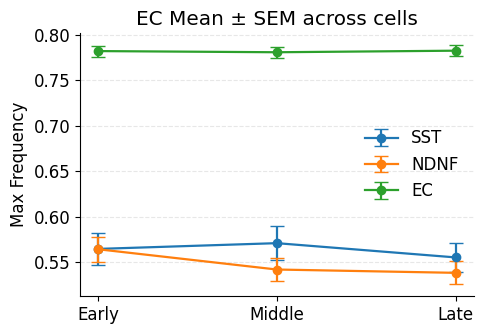

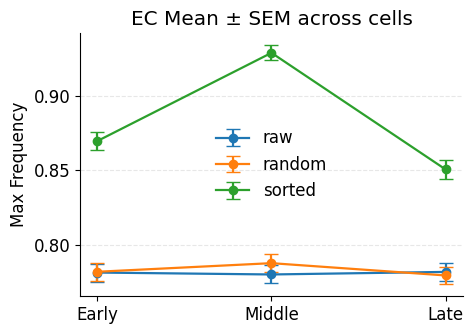

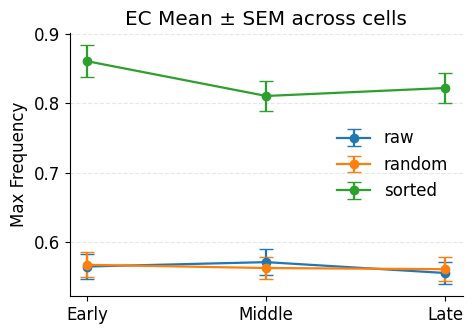

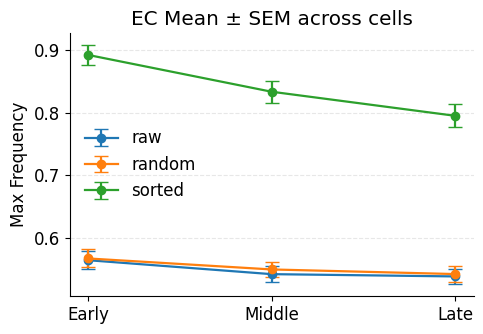

In [64]:
# maxes_array_EC_raw = np.array(maxes_list_EC_raw)

plot_mean_sem_three_list(maxes_list_SST_raw, maxes_list_NDNF_raw, maxes_list_EC_raw,
                         title="EC Mean ± SEM across cells",  ylabel="Max Frequency", show_cells=False, names = ["SST", "NDNF", "EC"])

plot_mean_sem_three_list(maxes_list_EC_raw, maxes_list_EC_random, maxes_list_EC_sorted,
                         title="EC Mean ± SEM across cells",  ylabel="Max Frequency", show_cells=False)

plot_mean_sem_three_list(maxes_list_SST_raw, maxes_list_SST_random, maxes_list_SST_sorted,
                         title="EC Mean ± SEM across cells",  ylabel="Max Frequency", show_cells=False)

plot_mean_sem_three_list(maxes_list_NDNF_raw, maxes_list_NDNF_random, maxes_list_NDNF_sorted,
                         title="EC Mean ± SEM across cells",  ylabel="Max Frequency", show_cells=False)


In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem

def plot_mean_sem_three(stoch_list, labels=("Early", "Middle", "Late"), ylabel="Stochasticity", title=None, show_cells=False):
    arr = np.asarray(stoch_list, dtype=float)               
    means = np.nanmean(arr, axis=0)                        
    sems  = sem(arr, axis=0, nan_policy="omit")             

    x = np.arange(3)

    fig, ax = plt.subplots(figsize=(5,3.5))
    ax.errorbar(x, means, yerr=sems, fmt="o", capsize=5, lw=1.6)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    ax.grid(True, axis="y", linestyle="--", alpha=0.3)

    if show_cells:
        for row in arr:
            plt.plot(np.arange(3), row, alpha=0.15, linewidth=1)

    plt.tight_layout()
    plt.show()

    return means, sems

# means_EC, sems_EC = plot_mean_sem_three(stoch_list_EC_raw, title="EC Mean ± SEM across cells", show_cells=False)
# means_EC, sems_EC = plot_mean_sem_three(stoch_list_EC, title="EC Mean ± SEM across cells", show_cells=True)

# means_SST, sems_SST = plot_mean_sem_three(stoch_list_SST, title="SST Mean ± SEM across cells", show_cells=False)
# means_SST, sems_SST = plot_mean_sem_three(stoch_list_SST, title="SST Mean ± SEM across cells", show_cells=True)

# means_NDNF, sems_NDNF = plot_mean_sem_three(stoch_list_NDNF, title="NDNF Mean ± SEM across cells", show_cells=False)
# means_NDNF, sems_NDNF = plot_mean_sem_three(stoch_list_NDNF, title="NDNF Mean ± SEM across cells", show_cells=True)



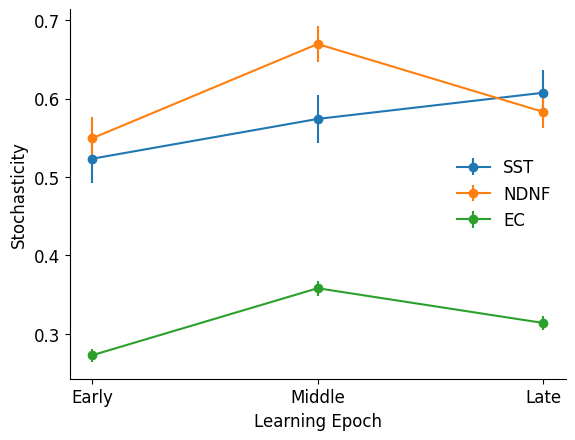

In [65]:
plt.errorbar(range(len(means_SST)), means_SST, yerr=sems_SST, marker='o', label="SST")
plt.errorbar(range(len(means_NDNF)), means_NDNF, yerr=sems_NDNF, marker='o', label="NDNF")
plt.errorbar(range(len(means_EC)), means_EC, yerr=sems_EC, marker='o', label="EC")
plt.ylabel("Stochasticity")
plt.xlabel("Learning Epoch")
plt.legend()
plt.xticks(np.arange(3), ["Early", "Middle", "Late"])
plt.show()


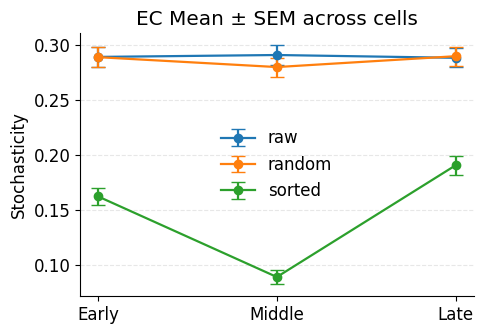

In [65]:


def plot_mean_sem_three_list(raw_list, rand_list, sorted_list,
                             phase_labels=("Early","Middle","Late"),
                             ylabel="Stochasticity", title=None, show_cells=False, names = ["raw", "random", "sorted"]):
    sets = [raw_list, rand_list, sorted_list]
    

    fig, ax = plt.subplots(figsize=(5, 3.5))
    x = np.arange(3)

    for name, data in zip(names, sets):
        arr = np.asarray(data, dtype=float)
        means = np.nanmean(arr, axis=0)
        errors = sem(arr, axis=0, nan_policy="omit")
        ax.errorbar(x, means, yerr=errors, fmt="o-", capsize=5, lw=1.6, label=name)
        if show_cells:
            for row in arr:
                ax.plot(x, row, alpha=0.12, linewidth=1)

    ax.set_xticks(x)
    ax.set_xticklabels(phase_labels)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    ax.grid(True, axis="y", linestyle="--", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_mean_sem_three_list(stoch_list_EC_raw, stoch_list_EC_random, stoch_list_EC_sorted,
                         title="EC Mean ± SEM across cells", show_cells=False)


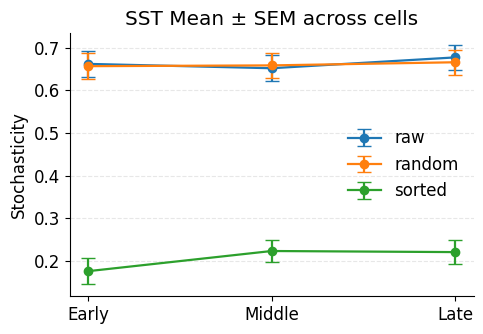

In [66]:

plot_mean_sem_three_list(stoch_list_SST_raw, stoch_list_SST_random, stoch_list_SST_sorted,
                         title="SST Mean ± SEM across cells", show_cells=False)

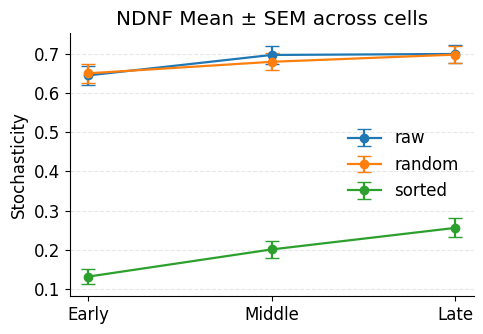

In [67]:

plot_mean_sem_three_list(stoch_list_NDNF_raw, stoch_list_NDNF_random, stoch_list_NDNF_sorted,
                         title="NDNF Mean ± SEM across cells", show_cells=False)

In [ ]:
###### report the highest number in the list 